In [2]:
!pip install pyspark
from pyspark.sql import SparkSession

spark =  SparkSession.builder.appName("CitiBike").getOrCreate()
print("Spark fungerer!")
print(spark.version)

Spark fungerer!
4.0.2


In [3]:
from genericpath import exists
import requests
import zipfile
import os

os.makedirs("citibike_data", exist_ok=True)

for month in range(1, 7):
  month_str = str(month).zfill(2)
  filename = f"2024{month_str}-citibike-tripdata.zip"
  url = f"https://s3.amazonaws.com/tripdata/{filename}"

  print(f"Downloading {filename}")
  response = requests.get(url)

  with open(filename, "wb") as f:
    f.write(response.content)

  with zipfile.ZipFile(filename, "r") as z:
    z.extractall("citibike_data")

  print(f"Done with {filename}!")

  print("All files were downloaded and packed out")

Done with 202401-citibike-tripdata.zip!
All files were downloaded and packed out
Done with 202402-citibike-tripdata.zip!
All files were downloaded and packed out
Done with 202403-citibike-tripdata.zip!
All files were downloaded and packed out
Done with 202404-citibike-tripdata.zip!
All files were downloaded and packed out
Done with 202405-citibike-tripdata.zip!
All files were downloaded and packed out
Done with 202406-citibike-tripdata.zip!
All files were downloaded and packed out


In [4]:
import os

files = os.listdir("citibike_data")
print(f"Amount of files: {len(files)}")
print("\nFiles")

total_size = 0
for f in files:
  filepath = os.path.join("citibike_data", f)
  size = os.path.getsize(filepath)
  total_size += size
  print(f"{f} - {size / (1024**2):.2f} MB")

  print(f"\nTotal size: {total_size / (1024**3):.2f} GB")

Amount of files: 22

Files
202403-citibike-tripdata_1.csv - 186.31 MB

Total size: 0.18 GB
202401-citibike-tripdata_1.csv - 186.32 MB

Total size: 0.36 GB
202405-citibike-tripdata_1.csv - 186.58 MB

Total size: 0.55 GB
202403-citibike-tripdata_2.csv - 186.48 MB

Total size: 0.73 GB
202405-citibike-tripdata_3.csv - 186.71 MB

Total size: 0.91 GB
202402-citibike-tripdata_3.csv - 22.56 MB

Total size: 0.93 GB
202405-citibike-tripdata_5.csv - 24.72 MB

Total size: 0.96 GB
202406-citibike-tripdata_5.csv - 146.46 MB

Total size: 1.10 GB
202406-citibike-tripdata_1.csv - 186.78 MB

Total size: 1.28 GB
202406-citibike-tripdata_3.csv - 186.45 MB

Total size: 1.46 GB
202401-citibike-tripdata_2.csv - 165.62 MB

Total size: 1.63 GB
202405-citibike-tripdata_4.csv - 186.73 MB

Total size: 1.81 GB
202406-citibike-tripdata_2.csv - 186.27 MB

Total size: 1.99 GB
202406-citibike-tripdata_4.csv - 186.73 MB

Total size: 2.17 GB
202403-citibike-tripdata_3.csv - 123.83 MB

Total size: 2.29 GB
202404-citibike

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
.appName("CitiBike") \
.config("spark.driver.memory", "4g") \
.getOrCreate()

print("Spark Restarted")

Spark Restarted


In [6]:
bike_df = spark.read.csv("citibike_data/*.csv", header=True, inferSchema=True)
print(f"Amount of rows: {bike_df.count()}")
print(f"Amount of columns: {len(bike_df.columns)}")

Amount of rows: 18807481
Amount of columns: 13


In [7]:
bike_df.printSchema()
bike_df = bike_df.dropna(subset=["start_station_name", "end_station_name"])

print(f"rows after removing of nulls: {bike_df.count()}")

root
 |-- ride_id: string (nullable = true)
 |-- rideable_type: string (nullable = true)
 |-- started_at: timestamp (nullable = true)
 |-- ended_at: timestamp (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_id: string (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_id: string (nullable = true)
 |-- start_lat: double (nullable = true)
 |-- start_lng: double (nullable = true)
 |-- end_lat: double (nullable = true)
 |-- end_lng: double (nullable = true)
 |-- member_casual: string (nullable = true)

rows after removing of nulls: 18758555


In [11]:
from pyspark.sql.functions import col, unix_timestamp, dayofweek, hour, date_format

bike_df = bike_df.withColumn(
    "trip_duration_mins",
    (unix_timestamp("ended_at") - unix_timestamp("started_at")) / 60
)

bike_df = bike_df.withColumn("day_of_week", date_format("started_at", "EEEE"))
bike_df = bike_df.withColumn("hour_of_day", hour("started_at"))

bike_df.select("started_at", "ended_at", "trip_duration_mins", "day_of_week", "hour_of_day").show(5)

+--------------------+--------------------+------------------+-----------+-----------+
|          started_at|            ended_at|trip_duration_mins|day_of_week|hour_of_day|
+--------------------+--------------------+------------------+-----------+-----------+
|2024-01-01 13:00:...|2024-01-01 13:04:...|               4.0|     Monday|         13|
|2024-01-08 19:36:...|2024-01-08 19:53:...|             16.55|     Monday|         19|
|2024-01-12 15:00:...|2024-01-12 15:36:...|              35.8|     Friday|         15|
|2024-01-12 16:52:...|2024-01-12 17:17:...|25.166666666666668|     Friday|         16|
|2024-01-05 19:50:...|2024-01-05 20:34:...| 44.38333333333333|     Friday|         19|
+--------------------+--------------------+------------------+-----------+-----------+
only showing top 5 rows


In [12]:
bike_df = bike_df.filter(
    (bike_df["trip_duration_mins"] > 1) &
    (bike_df["trip_duration_mins"] < 1440)
)

print(f"rows after filtering: {bike_df.count()}")

rows after filtering: 18758357


In [13]:
user_behaviour = bike_df.groupBy("member_casual") \
.agg(
    {"trip_duration_mins": "avg", "ride_id": "count"}
) \
.withColumnRenamed("avg(trip_duration_mins)", "avg_trip_duration_mins") \
.withColumnRenamed("count(ride_id)", "total_strips")

user_behaviour_pd = user_behaviour.toPandas()
print(user_behaviour_pd)

  member_casual  total_strips  avg_trip_duration_mins
0        casual       3431675               20.101532
1        member      15326682               11.322308


In [14]:
top_routes = bike_df.groupBy("start_station_name", "end_station_name") \
.count() \
.orderBy("count", ascending=False) \
.limit(5)

top_routes_pd = top_routes.toPandas()
print(top_routes_pd)

                  start_station_name                   end_station_name  count
0             Central Park S & 6 Ave             Central Park S & 6 Ave   6748
1         7 Ave & Central Park South         7 Ave & Central Park South   5381
2           Roosevelt Island Tramway           Roosevelt Island Tramway   4159
3              River Ter & Warren St           Vesey Pl & River Terrace   3378
4  Grand Army Plaza & Central Park S  Grand Army Plaza & Central Park S   3236


In [15]:
import sqlite3

user_behaviour_pd.to_sql(
    "user_behaviour",
    sqlite3.connect("citibike_summary.db"),
    if_exists="replace",
    index=False
)

print("Saved to citibike_summary.db!")

Saved to citibike_summary.db!


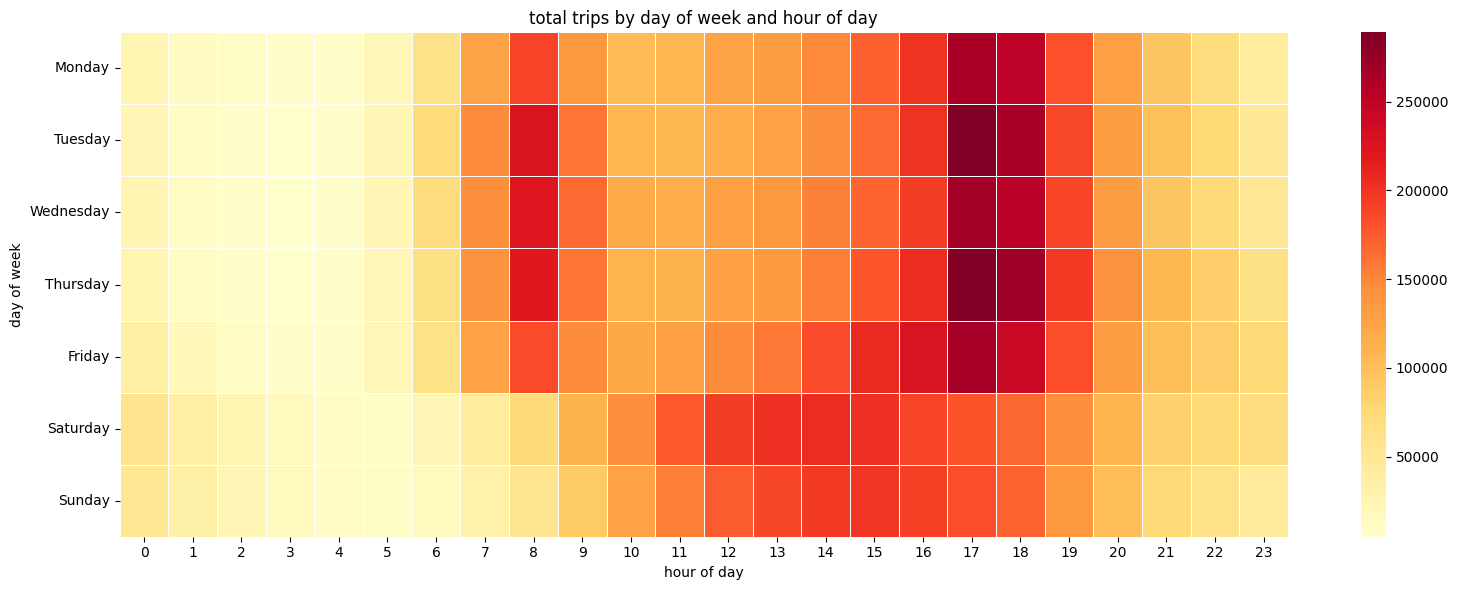

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

heatmap_data = bike_df.groupBy("day_of_week", "hour_of_day") \
.count() \
.toPandas()

heatmap_pivot = heatmap_data.pivot(index="day_of_week", columns="hour_of_day", values="count")
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_pivot = heatmap_pivot.reindex(day_order)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_pivot, cmap="YlOrRd", linewidths=0.5)
plt.title("total trips by day of week and hour of day")
plt.xlabel("hour of day")
plt.ylabel("day of week")
plt.tight_layout()
plt.show()

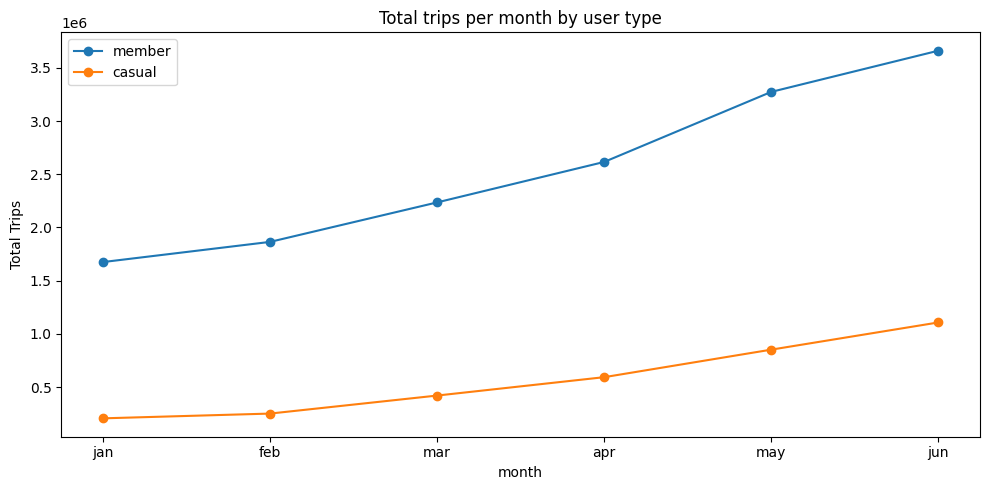

In [24]:
from pyspark.sql.functions import month

monthly_data = bike_df.groupBy(month("started_at").alias("month"), "member_casual") \
.count() \
.orderBy("month") \
.toPandas()
monthly_data = monthly_data[monthly_data["month"] <=6]

members = monthly_data[monthly_data["member_casual"] == "member"]
casuals = monthly_data[monthly_data["member_casual"] == "casual"]

plt.figure(figsize=(10, 5))
plt.plot(members["month"], members["count"], marker="o", label="member")
plt.plot(casuals["month"], casuals["count"], marker="o", label="casual")
plt.title("Total trips per month by user type")
plt.xlabel("month")
plt.ylabel("Total Trips")
plt.legend()
plt.xticks([1,2,3,4,5,6], ["jan", "feb", "mar", "apr", "may", "jun"])
plt.tight_layout()
plt.show()